# Exercises week 38

**FYS-STK3155/4155, fall 2026 — deadline Friday September 18 at midnight.**

## Adaptive learning rates and stochastic gradient descent

The aim this week is that you extend last week's gradient descent code with
the adaptive methods AdaGrad, RMSProp and Adam, that you understand what each
of them does to the step and why their learning rate is not the learning rate
of plain gradient descent, and that you replace the full gradient by a
minibatch gradient with epochs and a learning-rate schedule. Everything here is
reused directly in parts f) and h) of Project 1. The code developed in the
Tuesday session (`week38tuesday.ipynb`, Cases 1 and 2) is meant to be reused,
and the Monday notebook (`week38.ipynb`) contains worked examples of every
piece.

After completing these exercises you will have

* derived the bias correction of Adam and the first step of the adaptive
  methods, and shown why they are insensitive to the scale of a feature;
* your own implementation of AdaGrad, RMSProp and Adam in the same
  three-function structure as last week's gradient descent, checked against
  the closed-form solutions of OLS and Ridge;
* scanned the learning rate for each method and related the windows you find
  to $2/\lambda_{\max}$ (Section 4.5) and to what $\gamma$ means for an
  adaptive method (Sections 4.8–4.12);
* a stochastic gradient descent loop with minibatches, epochs and the
  schedule of Eq. (4.40), and studied the batch size and the schedule
  (Section 4.7);
* applied all of it to the Runge function at degree 10, the problem nothing
  converged on last week.

Reading: Chapter 4, Sections 4.7–4.13 of the book; Goodfellow et al.,
Sections 8.1–8.5.

## The data

We keep last week's function,

$$
f(x) = 2 - x + 5x^2, \qquad x \in [-2, 2],
$$

with $n = 100$ points and Gaussian noise of standard deviation $0.5$, fitted
with polynomial features of degree 2 (an easy problem, $\kappa \approx 1.3$)
and degree 5 (a hard one, $\kappa \approx 520$). As last week, standardise the
columns of the design matrix, centre $\boldsymbol{y}$ and use no intercept
column; the closed-form OLS and Ridge solutions are your reference.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    y_centered = y - y.mean()
    return X_norm, y_centered

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

X2, y2 = exercise_data(degree=2)
X5, y5 = exercise_data(degree=5)
for X in (X2, X5):
    eigs = hessian_eigs(X)
    print(f"degree {X.shape[1]}: kappa = {eigs.max() / eigs.min():.1f}, 2/lambda_max = {2 / eigs.max():.3f}")

degree 2: kappa = 1.3, 2/lambda_max = 0.894
degree 5: kappa = 520.3, 2/lambda_max = 0.354


## Exercise 1: what the adaptive methods do to the step (analytical)

The three adaptive methods replace the single learning rate $\gamma$ by a
per-coordinate step $\gamma/\sqrt{v_j}$, where $v_j$ estimates the second
moment of the gradient in coordinate $j$ (Section 4.8).

### 1a)

Unroll the RMSProp recursion of Eq. (4.47),
$\boldsymbol{v}_t = \rho\,\boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$ with
$\boldsymbol{v}_0 = \boldsymbol{0}$, to obtain Eq. (4.49),
$\boldsymbol{v}_t = (1-\rho)\sum_{j=1}^{t}\rho^{\,t-j}\boldsymbol{g}_j^2$, and show
that the weights sum to $1 - \rho^t$. After how many steps has a gradient's
weight fallen below $1/e$ of its initial weight, for $\rho = 0.9$ and
$\rho = 0.99$? Compare with AdaGrad's sum, Eq. (4.42), whose weights are all
one.

### 1b)

Now Adam. Assume the gradient is stationary with $\mathbb{E}[g^2]$ constant.
Take the expectation of the unrolled second moment of Eq. (4.52) and derive
Eq. (4.53), $\mathbb{E}[v_t] = (1-\beta_2^{\,t})\,\mathbb{E}[g^2]$. Do the same
for the first moment with $\beta_1$. Explain why dividing by $1-\beta_i^t$,
Eq. (4.54), removes the bias exactly, and evaluate the correction factors at
$t = 1$, $t = 10$ and $t = 1000$ for the default $\beta_1 = 0.9$,
$\beta_2 = 0.999$.

### 1c)

Show that the first step of Adam, Eq. (4.55) at $t = 1$, is
$\Delta\theta_j = -\gamma\,\mathrm{sign}(g_{1,j})$ (up to $\epsilon$),
independent of the size of the gradient, and that the same holds for AdaGrad.
What is the first step of RMSProp, which has no bias correction, with
$\rho = 0.99$? What does this tell you about the meaning of $\gamma$ for these
methods, compared with plain gradient descent? Without bias correction, by
what factor would Adam's first step be too long?

### 1d)

Multiply one feature (one column of $\boldsymbol{X}$) by a constant $c$. Show
that the corresponding component of the gradient of the OLS cost scales by
$c$ and that the AdaGrad/RMSProp/Adam step in that coordinate is unchanged,
whereas the plain gradient descent step scales by $c$ (and the stability bound
$2/\lambda_{\max}$ moves). Why does this *not* mean that standardising the
data is unnecessary for the adaptive methods? (Hint: the Tuesday session's
rotated bowl.)

## Exercise 2: implementing AdaGrad, RMSProp and Adam

Extend last week's code with one step function that holds all five
optimisers. The template below has the update rules to fill in; keep the
gradient as an argument so that the analytical gradient and `jax.grad` are
interchangeable, as in part e) of Project 1.

In [10]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        v = state.get("v", np.zeros_like(g))
        state["v"] = v = beta * v + gamma * g
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        r_o = state.get("r", np.zeros_like(g))
        state["r"] = r = r_o + g**2                           # Hvordan initialiserer jeg? 0 skal tilsvare r_0 
        return theta - (gamma/np.sqrt(eps + r))*g, state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        r_o = state.get("r", np.zeros_like(g))
        state["r"] = r = rho*r_o + (1-rho)*g**2              # 0 tilsvarer r_0
        return theta - (gamma/np.sqrt(eps + r))*g, state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        m_o = state.get("m", np.zeros_like(g))
        r_o = state.get("r", np.zeros_like(g))
        state["m"] = m = beta1*m_o + (1 - beta1)*g
        state["r"] = r = beta2*r_o + (1- beta2)*g**2
        m_hat, r_hat = m/(1 - beta1**t), r/(1 - beta2**t)
        return theta - (gamma/(np.sqrt(r_hat) + eps))*m_hat, state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t

### 2a)

Run all five methods on the degree-2 data for OLS and for Ridge with
$\lambda = 0.01$ (remember the $n\lambda\boldsymbol{I}$ of the closed form).
Use $\gamma = 0.5$ for plain gradient descent and momentum and try
$\gamma \in \{0.01, 0.1\}$ for the adaptive methods. Do all of them converge to
the closed-form solution? Plot the distance
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method.

In [11]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

Reference closed form Ridge: [-1.0596409   5.79468915]
Reference closed form OLS: [-1.0773505  5.854734 ]


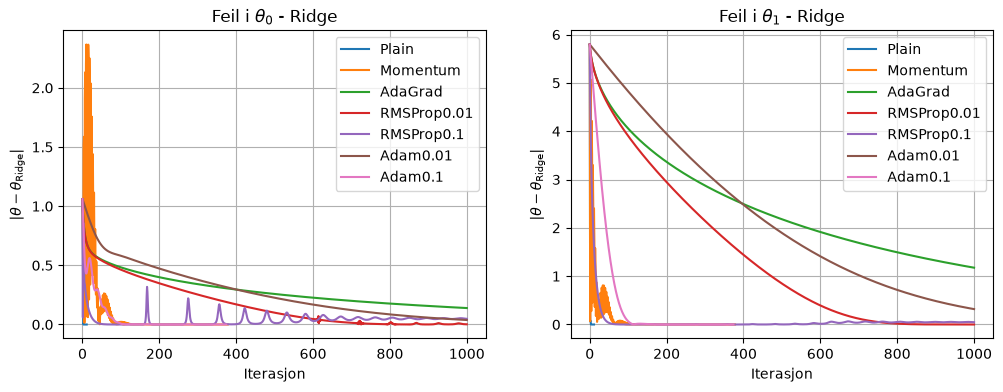

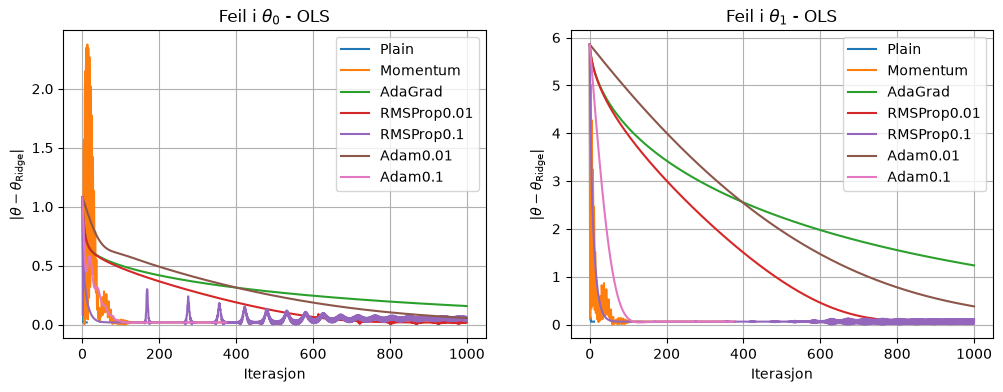

In [12]:
lmb = 0.01
gam = 0.5 # Plain gradient, momentum
gam_l = [0.01, 0.1] # adaptive methods

theta_2D_R = closed_form(X2, y2, lam=lmb)
theta_2D_O = closed_form(X2, y2, lam=0)
print("Reference closed form Ridge:", theta_2D_R)
print("Reference closed form OLS:", theta_2D_O)

degree = 2
theta0 = np.zeros(degree)
grad = lambda th: gradient(th, X2, y2, lam = lmb)

runs = {
    "Plain":    optimise(grad, theta0, "plain",    gamma=0.5)[0],
    "Momentum": optimise(grad, theta0, "momentum", gamma=0.5)[0],
    "AdaGrad":  optimise(grad, theta0, "adagrad",  gamma=0.1)[0],
    "RMSProp0.01": optimise(grad, theta0, "rmsprop",  gamma=0.01)[0],
    "RMSProp0.1":  optimise(grad, theta0, "rmsprop",  gamma=0.1)[0],
    "Adam0.01":     optimise(grad, theta0, "adam",     gamma=0.01)[0],
    "Adam0.1":     optimise(grad, theta0, "adam",     gamma=0.1)[0],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for name, history in runs.items():
    iterations = np.arange(len(history))
    error = np.abs(history - theta_2D_R)

    axes[0].plot(iterations, error[:, 0], label=name)
    axes[1].plot(iterations, error[:, 1], label=name)

axes[0].set_title(r"Feil i $\theta_0$ - Ridge")
axes[1].set_title(r"Feil i $\theta_1$ - Ridge")

for ax in axes:
    ax.set_xlabel("Iterasjon")
    ax.set_ylabel(r"$|\theta - \theta_{\mathrm{Ridge}}|$")
    ax.legend()
    ax.grid()

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for name, history in runs.items():
    iterations = np.arange(len(history))
    error = np.abs(history - theta_2D_O)

    axes[0].plot(iterations, error[:, 0], label=name)
    axes[1].plot(iterations, error[:, 1], label=name)

axes[0].set_title(r"Feil i $\theta_0$ - OLS")
axes[1].set_title(r"Feil i $\theta_1$ - OLS")

for ax in axes:
    ax.set_xlabel("Iterasjon")
    ax.set_ylabel(r"$|\theta - \theta_{\mathrm{Ridge}}|$")
    ax.legend()
    ax.grid()

plt.show()

### 2b)

Repeat for the degree-5 data ($\kappa = 520$), with $\gamma = 0.9 \cdot 2/\lambda_{\max}$
for plain descent and momentum. Report the number of iterations to reach
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$ for each method,
and identify the method that does not get there at a constant $\gamma$.
Explain why, using your result from exercise 1c).

Plain: nådde ikke error < 1e-6
Momentum: error < 1e-6 etter 286 iterasjoner


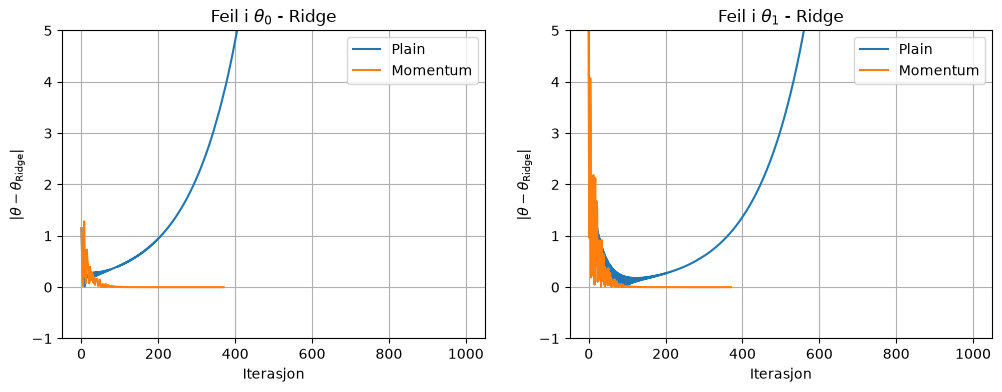

Plain: nådde ikke error < 1e-6
Momentum: error < 1e-6 etter 286 iterasjoner


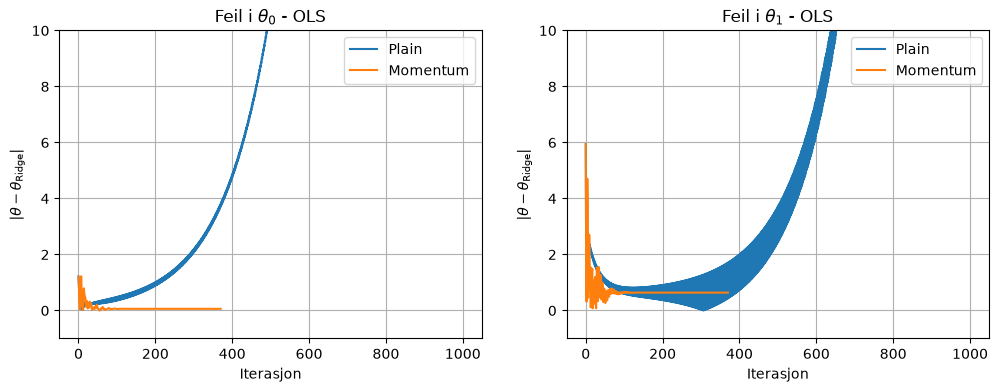

In [13]:
# Degree 5
# 2/= lambda_max = 0.354
lam = 0.01
theta5D_R = closed_form(X5, y5, lam=lam)
theta5D_O = closed_form(X5, y5, lam=0)
#print("Theta CF Ridge:", theta5D_R)
#print("Theta CF OLS:", theta5D_O)

gam = 0.354
degree = 5
theta0 = np.zeros(degree)
grad = lambda th: gradient(th, X5, y5, lam = lmb)

runs = {
    "Plain":    optimise(grad, theta0, "plain",    gamma=gam)[0],
    "Momentum": optimise(grad, theta0, "momentum", gamma=gam)[0],
}

#Ridge"
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for name, history in runs.items():
    iterations = np.arange(len(history))
    error = np.abs(history - theta5D_R)

    total_error = np.linalg.norm(history - theta5D_R, axis=1)  # Til stoppkravet
    reached = np.flatnonzero(total_error < 1e-6)
    if len(reached) > 0:
        print(f"{name}: error < 1e-6 etter {reached[0]} iterasjoner")
    else:
        print(f"{name}: nådde ikke error < 1e-6")

    axes[0].plot(iterations, error[:, 0], label=name)
    axes[1].plot(iterations, error[:, 1], label=name)

axes[0].set_title(r"Feil i $\theta_0$ - Ridge")
axes[1].set_title(r"Feil i $\theta_1$ - Ridge")

for ax in axes:
    ax.set_xlabel("Iterasjon")
    ax.set_ylabel(r"$|\theta - \theta_{\mathrm{Ridge}}|$")
    ax.set_ylim(-1, 5)
    ax.legend()
    ax.grid()

plt.show()

# OLS
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for name, history in runs.items():
    iterations = np.arange(len(history))
    error = np.abs(history - theta5D_O)

    total_error = np.linalg.norm(history - theta5D_R, axis=1)  # Til stoppkravet
    reached = np.flatnonzero(total_error < 1e-6)
    if len(reached) > 0:
        print(f"{name}: error < 1e-6 etter {reached[0]} iterasjoner")
    else:
        print(f"{name}: nådde ikke error < 1e-6")
    
    axes[0].plot(iterations, error[:, 0], label=name)
    axes[1].plot(iterations, error[:, 1], label=name)

axes[0].set_title(r"Feil i $\theta_0$ - OLS")
axes[1].set_title(r"Feil i $\theta_1$ - OLS")

for ax in axes:
    ax.set_xlabel("Iterasjon")
    ax.set_ylabel(r"$|\theta - \theta_{\mathrm{Ridge}}|$")
    ax.set_ylim(-1, 10)
    ax.legend()
    ax.grid()

plt.show()



### 2c)

Check one method against a library implementation: for the degree-2 OLS
problem, run `optax.adam` (or `torch.optim.Adam`, or any other) with the same
$\gamma$, $\beta_1$, $\beta_2$ and $\epsilon$ from the same starting point, and
compare the first ten iterates with your own. They should agree to rounding.
If they do not, the usual suspects are the bias correction and the placement
of $\epsilon$ (inside or outside the square root).

In [14]:
import optax

# Samme problem og hyperparametere i begge implementasjoner
gamma = 0.01         
beta1 = 0.9
beta2 = 0.999
eps = 1e-8
n_steps = 10

X_jax = jnp.asarray(X2)
y_jax = jnp.asarray(y2)
theta0 = jnp.zeros(X2.shape[1])

def cost_jax(theta, X, y, lam=0.0):
    return jnp.mean((X @ theta - y)**2) + lam * jnp.dot(theta, theta)

grad_jax = jax.grad(cost_jax)
grad = lambda theta: grad_jax(theta, X_jax, y_jax, lam=0.0)

# Din implementasjon: history[0] er startpunktet, deretter 10 oppdateringer
own_history, _ = optimise(
    grad, theta0, "adam", gamma,
    num_iters=n_steps, tol=0,
    beta1=beta1, beta2=beta2, eps=eps
)

# Optax sin implementasjon
adam_optax = optax.adam(
    learning_rate=gamma, b1=beta1, b2=beta2, eps=eps
)

theta = theta0                      # Theta startverdi (0)
state = adam_optax.init(theta)      # Optax startverdi, tilstand
optax_history = [np.asarray(theta)] # En array for å lagre utivklingen til theta

for _ in range(n_steps):
    g = grad(theta)  # Gradient
    updates, state = adam_optax.update(g, state, theta)
    theta = optax.apply_updates(theta, updates)
    optax_history.append(np.asarray(theta))

optax_history = np.array(optax_history)

# Sammenlign de ti første oppdateringene
for k in range(1, n_steps + 1):
    difference = np.max(np.abs(own_history[k] - optax_history[k]))
    print(f"Iterasjon {k}: største forskjell = {difference:.2e}")

print("\nLike iterater?", np.allclose(own_history, optax_history))

Iterasjon 1: største forskjell = 0.00e+00
Iterasjon 2: største forskjell = 0.00e+00
Iterasjon 3: største forskjell = 0.00e+00
Iterasjon 4: største forskjell = 0.00e+00
Iterasjon 5: største forskjell = 0.00e+00
Iterasjon 6: største forskjell = 0.00e+00
Iterasjon 7: største forskjell = 0.00e+00
Iterasjon 8: største forskjell = 0.00e+00
Iterasjon 9: største forskjell = 0.00e+00
Iterasjon 10: største forskjell = 0.00e+00

Like iterater? True


## Exercise 3: the learning rate means something different to each method

### 3a)

For the degree-5 OLS problem, scan $\gamma$ over a logarithmic grid from
$10^{-3}$ to $1$ (about fifteen values) for each of the five methods, and
record the number of iterations to $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$
(or "did not converge" within 20 000 iterations). Plot iterations against
$\gamma$ for all methods in one figure, on logarithmic axes.

/Users/timholmen/MachineLearningUiO/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/var/folders/ck/22n3y2ds5rsdcncmzd05zghc0000gn/T/ipykernel_51199/1518774829.py:26: RuntimeWarning: overflow encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
/var/folders/ck/22n3y2ds5rsdcncmzd05zghc0000gn/T/ipykernel_51199/1518774829.py:26: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
/var/folders/ck/22n3y2ds5rsdcncmzd05zghc0000gn/T/ipykernel_51199/1518774829.py:26: RuntimeWarning: invalid value encountered in multiply
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
/Users/timholmen/MachineLearningUiO/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/timholmen/MachineLearningUiO/.venv/lib/python3.13/site-packag

Plain klarte det etter [nan, nan, nan, nan, nan, nan, nan, nan, nan, np.int64(13862), np.int64(8461), np.int64(5163), nan, nan, nan] iterasjoner
Momentum klarte det etter [nan, nan, nan, nan, np.int64(16234), np.int64(9867), np.int64(5979), np.int64(3605), np.int64(2153), np.int64(1263), np.int64(713), np.int64(346), np.int64(281), np.int64(288), nan] iterasjoner
AdaGrad klarte det etter [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.int64(16346), np.int64(7199), np.int64(5954)] iterasjoner
RMSProp klarte det etter [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan] iterasjoner
Adam klarte det etter [np.int64(16496), np.int64(13843), np.int64(11812), np.int64(10071), np.int64(8471), np.int64(6955), np.int64(5516), np.int64(4181), np.int64(3006), np.int64(2049), np.int64(1338), np.int64(847), np.int64(500), np.int64(452), np.int64(511)] iterasjoner


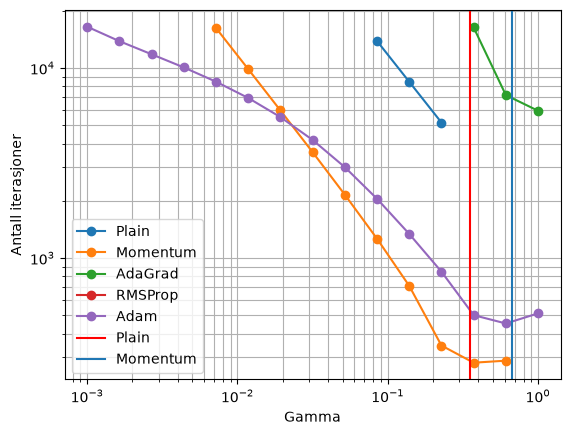

In [15]:
gam3 = np.logspace(-3,0,15)
lmb = 0 # OLS Problem

degree = 5
theta0 = np.zeros(degree)
grad = lambda th: gradient(th, X5, y5, lam = 0.0)
it_R = {}
n_i = 20000
def run_throug_gamlog(gamma):
    runs = {
        "Plain":    optimise(grad, theta0, "plain",    gamma=gamma, num_iters=n_i)[0],
        "Momentum": optimise(grad, theta0, "momentum", gamma=gamma, num_iters=n_i)[0],
        "AdaGrad":  optimise(grad, theta0, "adagrad",  gamma=gamma, num_iters=n_i)[0],
        "RMSProp": optimise(grad, theta0, "rmsprop",  gamma=gamma, num_iters=n_i)[0],
        "Adam":     optimise(grad, theta0, "adam",     gamma=gamma, num_iters=n_i)[0],
    }
    for name, history in runs.items():
        iterations = np.arange(len(history))
        error = np.abs(history - theta5D_O)

        total_error = np.linalg.norm(history - theta5D_O, axis=1)
        reached = np.flatnonzero(total_error < 1e-6)
        if len(reached) > 0:
            it_R[name]= (reached[0])
        else:
            it_R[name]=np.nan
        
    return it_R

resultater = {
    "Plain": [],
    "Momentum": [],
    "AdaGrad": [],
    "RMSProp": [],
    "Adam": []
}

for gam in gam3:
    itera = run_throug_gamlog(gam)

    for metode, iterasjon in itera.items():
        resultater[metode].append(iterasjon)


for metode, iterasjon in resultater.items():
    it = resultater[metode]
    print(f"{metode} klarte det etter {iterasjon} iterasjoner")
    plt.loglog(gam3, iterasjon, marker="o", label = metode)

plt.xlabel("Gamma")
plt.ylabel("Antall iterasjoner")
beta=0.9
plt.axvline(2 / eigs.max(), color="red",label = "Plain")
plt.axvline(2*(1+beta) / eigs.max(), label ="Momentum")
plt.legend()
plt.grid(True, which="both")
plt.show()




Windof of usable $\gamma$ 
Plain: [0.1,0.4] 
Momentum: [0.01,0.8] 
Adagrad: [0.6,1.0] 
RMSProp: [Nan]
Adam[0.001,1] - Whole Range

All methods have their minimum iterations around the best values, strangely
momentum has the least iterations around the plain learning rate, while adam has its miniumum near the momentum learning rate. 
Adam is least sensitive to the learning rate, but adam is not its fastest
at its best learning rate, that is momentum with 346 iterations. Adam dit 452 iterations at its best. Strangely enough all methods
have rather high number of iterations, this may be a result of the high degree of the polynomial.   



### 3b)

Discuss the figure: where does each method's window of usable $\gamma$ start
and end, and how do the edges relate to $2/\lambda_{\max}$ (plain descent),
$2(1+\beta)/\lambda_{\max}$ (momentum), and to the fact that the adaptive
methods take steps of length at most $\gamma$ per coordinate? Which method is
the least sensitive to $\gamma$, and is it also the fastest at its best
$\gamma$?

### 3c)

Book Table 4.1 and Figure 4.7 compare the five methods at three learning
rates on a problem with $\kappa = 12$ and find that the ranking reverses
between $\gamma = 0.01$ and $\gamma = 0.5$. Reproduce this behaviour on your
degree-2 data (where $\kappa = 1.3$): which method is best at each $\gamma$, and
what is the lesson for how optimisers should be compared in Project 1?

In [16]:
# Your code for exercise 3 here

gam_rev = [0.01, 0.1, 0.5]
degree = 2
theta0 = np.zeros(degree)
grad = lambda th: gradient(th, X2, y2, lam = 0.0)
n_i = 20000
def run_throug_gam(gamma):
    it_R = {}
    runs = {
        "Plain":    optimise(grad, theta0, "plain",    gamma=gamma, num_iters=n_i)[0],
        "Momentum": optimise(grad, theta0, "momentum", gamma=gamma, num_iters=n_i)[0],
        "AdaGrad":  optimise(grad, theta0, "adagrad",  gamma=gamma, num_iters=n_i)[0],
        "RMSProp": optimise(grad, theta0, "rmsprop",  gamma=gamma, num_iters=n_i)[0],
        "Adam":     optimise(grad, theta0, "adam",     gamma=gamma, num_iters=n_i)[0],
    }
    for name, history in runs.items():
        iterations = np.arange(len(history))
        error = np.abs(history - theta_2D_O)

        total_error = np.linalg.norm(history - theta_2D_O, axis=1)
        reached = np.flatnonzero(total_error < 1e-6)
        if len(reached) > 0:
            it_R[name]= (reached[0])
        else:
            it_R[name]=np.nan
        
    return it_R

resultater = {
    "Plain": [],
    "Momentum": [],
    "AdaGrad": [],
    "RMSProp": [],
    "Adam": []
}

for gam in gam_rev:
    itera = run_throug_gam(gam)

    for metode, iterasjon in itera.items():
        resultater[metode].append(iterasjon)

for i, gamma in enumerate(gam_rev):
    gyldige = {
        metode: iterasjoner[i]
        for metode, iterasjoner in resultater.items()
        if not np.isnan(iterasjoner[i])
    }

    beste_metode = min(gyldige, key=gyldige.get)

    print(f"Gamma = {gamma}: {beste_metode} "
          f"({gyldige[beste_metode]} iterasjoner)")

for metode, iterasjon in resultater.items():
    print(metode, (iterasjon[0]), iterasjon[1], iterasjon[2])



Gamma = 0.01: Momentum (288 iterasjoner)
Gamma = 0.1: Plain (80 iterasjoner)
Gamma = 0.5: Plain (8 iterasjoner)
Plain 867 80 8
Momentum 288 222 264
AdaGrad nan 13553 632
RMSProp nan 129 13
Adam 2606 286 245


## Exercise 4: stochastic gradient descent

Replace the full gradient by a minibatch gradient, Eq. (4.33), inside an
epoch loop. Reshuffle the data every epoch and split the shuffled indices into
minibatches of size $M$; the update of Eq. (4.34) is one call to your
`optimiser_step`, so every optimiser of exercise 2 works with minibatches
unchanged.

In [17]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1): # Avtakende learning rate
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            X_batch, y_batch = X[batch], y[batch]
            g = gradient(theta, X_batch, y_batch, lam=lam)
            gamma_t = gamma if schedule is None else step_length(t - 1, *schedule)
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)

### 4a)

At a fixed point $\boldsymbol{\theta} = (0, 3)$ of the degree-2 problem,
compute the gradient on many random minibatches of size $M = 1, 5, 25$ and
compare their mean and their spread (standard deviation over batches) with the
full gradient. Verify numerically that the spread falls as $1/\sqrt{M}$, and say
in one sentence what this means for the trade-off between batch size and cost
per step.

In [18]:
# Exercise 4
# All distances below are measured relative to the closed-form OLS solution.
theta2_ols = closed_form(X2, y2, lam=0.0)
theta5_ols = closed_form(X5, y5, lam=0.0)

# 4a) Minibatch gradients are unbiased, while their noise decreases with M.
theta_fixed = np.array([0.0, 3.0])
full_g = gradient(theta_fixed, X2, y2)
rng = np.random.default_rng(2026)
print('4a: full gradient =', full_g)
"""for M in (1, 5, 25):
    batch_gradients = np.array([
        gradient(theta_fixed, X2[idx], y2[idx])
        for idx in (rng.choice(len(y2), size=M, replace=False) for _ in range(2000))
    ])
    mean_g = batch_gradients.mean(axis=0)
    spread = batch_gradients.std(axis=0)
    print(f'M={M:2d}: mean = {mean_g}, std = {spread}, ||std||*sqrt(M) = {np.linalg.norm(spread)*np.sqrt(M):.3g}')
print("-----")"""
for M in (1, 5, 25):
    gradienter = []
    for _ in range(2000):
        idx = rng.choice(len(y2), size=M, replace=False)
        X_batch = X2[idx]
        y_batch = y2[idx]

        g = gradient(theta_fixed, X_batch, y_batch)
        gradienter.append(g)
    batch_gradients = np.array(gradienter)

    mean_g = batch_gradients.mean(axis=0)
    spread = batch_gradients.std(axis=0)

    print(f"M={M}:")
    print("  Gjennomsnittlig gradient:", mean_g)
    print("  Standardavvik:", spread)
    print(f"||std||*sqrt(M) = {np.linalg.norm(spread)*np.sqrt(M):.3g}")

# The approximately constant final quantity confirms std(minibatch gradient) ∝ 1/sqrt(M).
# Larger batches therefore give less noisy but more expensive updates.

# Helper: distance at the end of every epoch.
def distances(history, theta_star):
    return np.linalg.norm(history - theta_star, axis=1)


4a: full gradient = [ 1.47833066 -5.45421202]


M=1:
  Gjennomsnittlig gradient: [ 1.58849747 -5.87931813]
  Standardavvik: [9.13982198 8.86107133]
||std||*sqrt(M) = 12.7
M=5:
  Gjennomsnittlig gradient: [ 1.49439674 -5.46351003]
  Standardavvik: [3.92488465 3.69873179]
||std||*sqrt(M) = 12.1
M=25:
  Gjennomsnittlig gradient: [ 1.45147422 -5.43013114]
  Standardavvik: [1.46529067 1.43675215]
||std||*sqrt(M) = 10.3


M=1:
èn tilfeldig Verdi av X og Y plukkes ut og gradienten beregnes 2000 ganger.
Matrisemultiplikasjonen for gradienten er dermed skalar multiplikasjon.
M = 5:
fem uavhengige tilfeldige verdier av X og Y plukkes ut og gradienten beregnes 2000 ganger. x og y er henholdsvis 5x2 og 5x1 matriser. Multiplikasjonen for å beregne gradienten er matrise / vector multiplikasjon, og krever mer datakraft.
M = 25:
tjuefem uavhengige tilfeldige verdier av X og y plukkes ut og gradienten beregnes 2000 ganger. Nå har vi 25x2 og 25x1 matriser. Multiplikasjonen krever enda mer datakraft.
$(2.0 / n) * X.T @ (X @ \theta - y) + 2.0 * \lambda * \theta$ for theta er lik 0 og 3 som tilsvarer $y = 0 + 3x = 3x$

Samtidig gir større batch betraktelig lavere spredning.

### 4b)

Run plain SGD with $M = 5$ on the degree-2 data for 100 epochs at
$\gamma = 0.1$ and at $\gamma = 0.02$, and plot the distance to the closed-form
solution against the number of *single-point gradient evaluations* (epochs
times $n$) together with full-batch gradient descent at $\gamma = 0.5$. Which
method is ahead early, which is ahead late, and does SGD with a constant
learning rate converge at all? Relate the size of the plateau to $\gamma$.

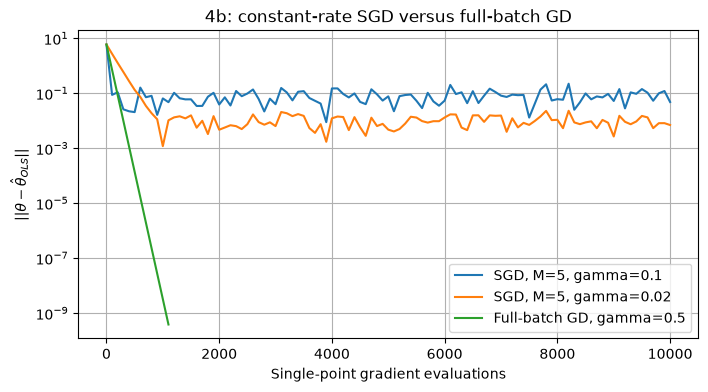

4b final distances: {'SGD 0.1': np.float64(0.04810839113216645), 'SGD 0.02': np.float64(0.00697939857484422), 'full GD': np.float64(3.8389835872538816e-10)}


In [19]:
# 4b) Compare work using single-point gradient evaluations as the horizontal axis.
n_epochs = 100
batch_size = 5
sgd_01 = sgd(X2, y2, method='plain', n_epochs=n_epochs, batch_size=batch_size, gamma=0.1)
sgd_002 = sgd(X2, y2, method='plain', n_epochs=n_epochs, batch_size=batch_size, gamma=0.02)
gd = optimise(lambda th: gradient(th, X2, y2), np.zeros(X2.shape[1]),
              'plain', gamma=0.5, num_iters=n_epochs)[0]
work = np.arange(n_epochs + 1) * len(y2)
work_gd = np.arange(len(gd)) * len(y2)  # optimise stops early after convergence

plt.figure(figsize=(8, 4))
plt.semilogy(work, distances(sgd_01, theta2_ols), label='SGD, M=5, gamma=0.1')
plt.semilogy(work, distances(sgd_002, theta2_ols), label='SGD, M=5, gamma=0.02')
plt.semilogy(work_gd, distances(gd, theta2_ols), label='Full-batch GD, gamma=0.5')
plt.xlabel('Single-point gradient evaluations')
plt.ylabel(r'$||\theta - \hat\theta_{OLS}||$')
plt.title('4b: constant-rate SGD versus full-batch GD')
plt.grid(True, which='both')
plt.legend()
plt.show()
print('4b final distances:', {'SGD 0.1': distances(sgd_01, theta2_ols)[-1], 'SGD 0.02': distances(sgd_002, theta2_ols)[-1], 'full GD': distances(gd, theta2_ols)[-1]})

# Constant-rate SGD reaches a noise plateau instead of converging exactly;
# the gamma=0.02 plateau should be smaller than the gamma=0.1 plateau.


### 4c)

Now the schedule of Eq. (4.40). With $(t_0, t_1) = (1, 10)$ the initial
learning rate is $0.1$. Add this run to the plot of 4b). Then move to the
degree-5 data and run the same schedule: what happens? Find a pair $(t_0, t_1)$
with the same initial learning rate that works there, and explain your choice
in terms of the Robbins–Monro conditions $\sum_t \gamma_t = \infty$,
$\sum_t \gamma_t^2 < \infty$.

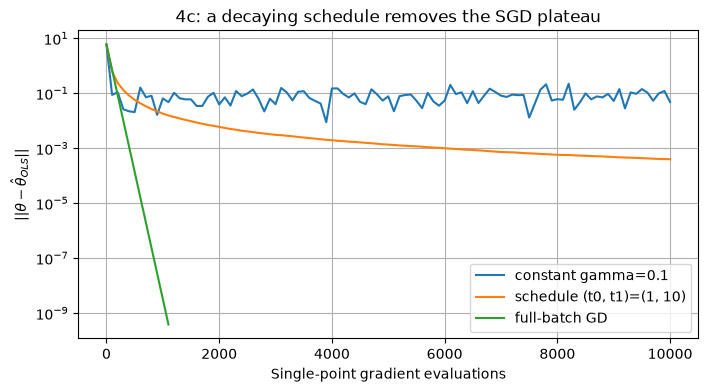

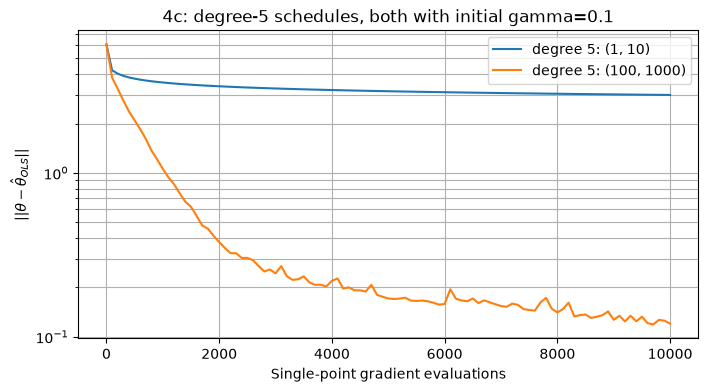

4c final degree-5 distances: {'(1, 10)': np.float64(2.9871619223445953), '(100, 1000)': np.float64(0.12031487533037248)}


In [20]:
# 4c) gamma_t = t0 / (t + t1), where t starts at zero.
# Hence (1, 10) starts at gamma_0 = 0.1.
sgd_schedule_2 = sgd(X2, y2, method='plain', n_epochs=n_epochs, batch_size=5, schedule=(1, 10))
plt.figure(figsize=(8, 4))
plt.semilogy(work, distances(sgd_01, theta2_ols), label='constant gamma=0.1')
plt.semilogy(work, distances(sgd_schedule_2, theta2_ols), label='schedule (t0, t1)=(1, 10)')
plt.semilogy(work_gd, distances(gd, theta2_ols), label='full-batch GD')
plt.xlabel('Single-point gradient evaluations')
plt.ylabel(r'$||\theta - \hat\theta_{OLS}||$')
plt.title('4c: a decaying schedule removes the SGD plateau')
plt.grid(True, which='both')
plt.legend()
plt.show()

# At degree 5, (1, 10) decays too quickly.  Scaling both values retains
# gamma_0=t0/t1=0.1 but postpones the decay.
sgd_schedule_5_fast_decay = sgd(X5, y5, method='plain', n_epochs=n_epochs, batch_size=5, schedule=(1, 10))
sgd_schedule_5_slow_decay = sgd(X5, y5, method='plain', n_epochs=n_epochs, batch_size=5, schedule=(100, 1000))
work5 = np.arange(n_epochs + 1) * len(y5)
plt.figure(figsize=(8, 4))
plt.semilogy(work5, distances(sgd_schedule_5_fast_decay, theta5_ols), label='degree 5: (1, 10)')
plt.semilogy(work5, distances(sgd_schedule_5_slow_decay, theta5_ols), label='degree 5: (100, 1000)')
plt.xlabel('Single-point gradient evaluations')
plt.ylabel(r'$||\theta - \hat\theta_{OLS}||$')
plt.title('4c: degree-5 schedules, both with initial gamma=0.1')
plt.grid(True, which='both')
plt.legend()
plt.show()
print('4c final degree-5 distances:', {'(1, 10)': distances(sgd_schedule_5_fast_decay, theta5_ols)[-1], '(100, 1000)': distances(sgd_schedule_5_slow_decay, theta5_ols)[-1]})
# t0/(t+t1) satisfies the Robbins-Monro conditions: its sum diverges,
# while the sum of its squares converges.  Larger t0,t1 merely delay decay.


### 4d)

Study the batch size on the degree-5 data at $\gamma = 0.1$: $M \in \{1, 5, 20, 100\}$
for 100 epochs. One of these runs diverges although $\gamma$ is below
$2/\lambda_{\max}$ of the full Hessian. Which Hessian is relevant for a single
minibatch step, and what is its largest eigenvalue for $M = 1$? (For a single
point it is $2\|\boldsymbol{x}_i\|^2$.)


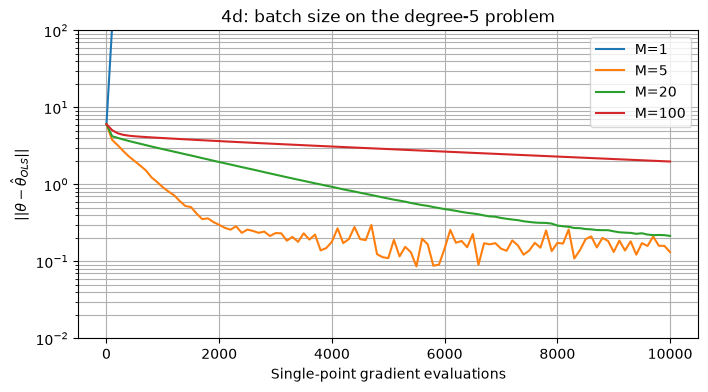

4d: largest single-point Hessian eigenvalue = 85.7; stability bound = 0.02334


In [21]:
# 4d) Batch-size experiment on degree 5.
batch_sizes = (1, 5, 20, 100)
runs_4d = {M: sgd(X5, y5, method='plain', n_epochs=100, batch_size=M, gamma=0.1) for M in batch_sizes}
plt.figure(figsize=(8, 4))
for M, history in runs_4d.items():
    plt.semilogy(np.arange(len(history)) * len(y5), distances(history, theta5_ols), label=f'M={M}')
plt.xlabel('Single-point gradient evaluations')
plt.ylabel(r'$||\theta - \hat\theta_{OLS}||$')
plt.title('4d: batch size on the degree-5 problem')
plt.grid(True, which='both')
plt.ylim(10**-2,10**2)
plt.legend()
plt.show()
point_eigs = 2 * np.sum(X5**2, axis=1)
print(f'4d: largest single-point Hessian eigenvalue = {point_eigs.max():.4g}; stability bound = {2 / point_eigs.max():.4g}')
# A single-point step sees H_i = 2 x_i x_i^T, not the full-data Hessian.


### 4e)

Combine SGD with Adam on the degree-5 data ($M = 5$, $\gamma \in \{0.01, 0.05\}$,
100 epochs) and compare with plain SGD and with momentum. Which combination
comes closest to the closed-form solution, and which one fails? This is the
setting of Project 1, part h).

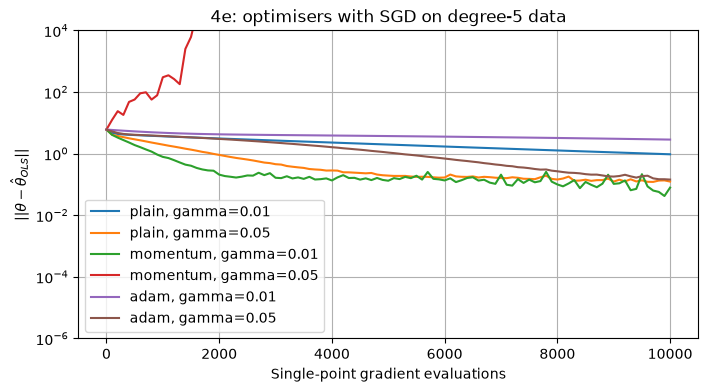

4e: ('momentum', 0.01): final distance = 7.920e-02
4e: ('plain', 0.05): final distance = 1.245e-01
4e: ('adam', 0.05): final distance = 1.444e-01
4e: ('plain', 0.01): final distance = 9.570e-01
4e: ('adam', 0.01): final distance = 2.872e+00
4e: ('momentum', 0.05): final distance = 3.490e+19
Closest after 100 epochs: ('momentum', 0.01); failed/diverged runs have inf or nan distances.


In [22]:

# 4e) Compare plain SGD, momentum SGD and Adam SGD on the same minibatches.
methods = ('plain', 'momentum', 'adam')
gammas = (0.01, 0.05)
runs_4e = {(method, gamma): sgd(X5, y5, method=method, n_epochs=100, batch_size=5, gamma=gamma)
           for method in methods for gamma in gammas}
plt.figure(figsize=(8, 4))
for (method, gamma), history in runs_4e.items():
    plt.semilogy(np.arange(len(history)) * len(y5), distances(history, theta5_ols),
                 label=f'{method}, gamma={gamma}')
plt.xlabel('Single-point gradient evaluations')
plt.ylabel(r'$||\theta - \hat\theta_{OLS}||$')
plt.title('4e: optimisers with SGD on degree-5 data')
plt.grid(True, which='both')
plt.ylim(10**(-6),10**4)
plt.legend()
plt.show()

final_4e = {(method, gamma): distances(history, theta5_ols)[-1]
            for (method, gamma), history in runs_4e.items()}
for setting, final_distance in sorted(final_4e.items(), key=lambda item: item[1]):
    print(f'4e: {setting}: final distance = {final_distance:.3e}')
best_setting = min(final_4e, key=final_4e.get)
print(f'Closest after 100 epochs: {best_setting}; failed/diverged runs have inf or nan distances.')


## Exercise 5: the Runge function at degree 10 (Project 1, parts f and h)

Last week nothing converged on the Runge function $f(x) = 1/(1+25x^2)$ on
$[-1, 1]$ ($n = 100$, noise $0.1$) with a degree-10 polynomial:
$\kappa \approx 2 \times 10^6$. Use the Tuesday session's `runge_data` (the same
standardisation as above).

In [23]:
def runge_data(n=100, degree=10, noise=0.1, seed=2026):
    """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()



### 5a)

Run momentum and Adam with the full gradient for 30 000 iterations and plot
the excess cost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$
against the iteration. What accuracy do they reach, and does either of them
resolve the flat directions? Explain, with the rotated bowl of the Tuesday
session in mind, why a diagonal rescaling cannot fix a problem whose
ill-conditioning comes from strongly correlated columns.

Momentum: excess cost = 2.837e-03, ||theta - theta_OLS|| = 3.333e+01
Adam: excess cost = 1.466e-03, ||theta - theta_OLS|| = 2.413e+01


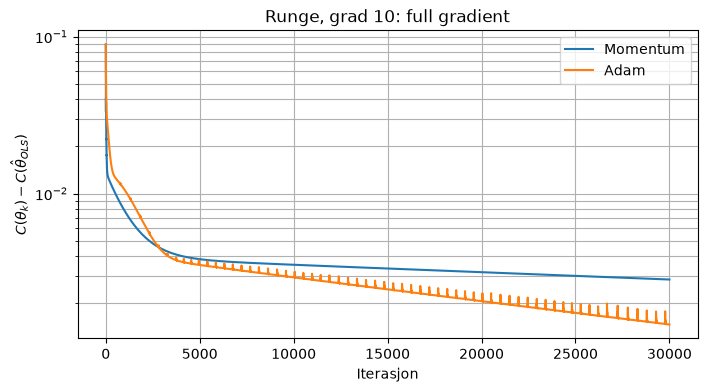

In [30]:
def runge_comparison(degree=10, num_iters=30000, lam=0):
    # Samme data og startpunkt for begge metodene; lam=0 gir OLS.
    X, y = runge_data(degree=degree)
    theta_cf = closed_form(X, y)
    cost_cf = cost(theta_cf, X, y)
    theta0 = np.zeros(X.shape[1])
    grad = lambda theta: gradient(theta, X, y, lam)

    #from time import perf_counter

    runs = {}
    for name, method, gamma in [("Momentum", "momentum", 0.1),
                                ("Adam", "adam", 0.01)]:
        #print(f"Starter {name}: {num_iters} iterasjoner ...", flush=True)
        #start = perf_counter()
        history, steps = optimise(grad, theta0, method, gamma=gamma,
                                  num_iters=num_iters, tol=0)
        runs[name] = history
        #print(f"{name}: {steps} iterasjoner på "
        #      f"{perf_counter() - start:.2f} s", flush=True)

    #print("Beregner kostnader og lager plott ...", flush=True)

    plt.figure(figsize=(8, 4))
    for name, history in runs.items():
        # Én kostnadsforskjell for hver lagrede theta, inkludert startpunktet.
        excess_cost = np.array([cost(theta, X, y) - cost_cf
                                for theta in history])
        plt.semilogy(np.arange(len(history)),
                     np.maximum(excess_cost, 1e-16), label=name)
        parameter_error = np.linalg.norm(history[-1] - theta_cf)
        print(f"{name}: excess cost = {excess_cost[-1]:.3e}, "
              f"||theta - theta_OLS|| = {parameter_error:.3e}")

    plt.xlabel("Iterasjon")
    plt.ylabel(r"$C(\theta_k) - C(\hat{\theta}_{OLS})$")
    plt.title(f"Runge, grad {degree}: full gradient")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()
    return runs

runs = runge_comparison(degree=10, num_iters=30000, lam=0)


### 5b)

Add Ridge with $\lambda \in \{10^{-3}, 10^{-2}\}$: what are the condition
numbers now, and how many iterations do momentum and Adam need to reach an
excess cost of $10^{-8}$? Compare the Ridge coefficients with the OLS ones and
discuss whether Ridge is "cheating" — what problem has it solved, and is that
the problem you wanted solved? (Part i) of Project 1 answers the last question
with cross-validation.)

Momentum: excess cost = 1.790e-02, ||theta - theta_OLS|| = 3.941e+01
Adam: excess cost = 1.790e-02, ||theta - theta_OLS|| = 3.941e+01


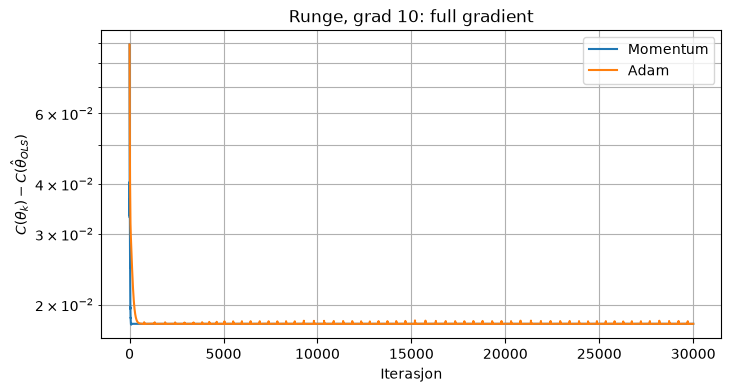

-----
Momentum: excess cost = 1.790e-02, ||theta - theta_OLS|| = 3.941e+01
Adam: excess cost = 1.790e-02, ||theta - theta_OLS|| = 3.941e+01


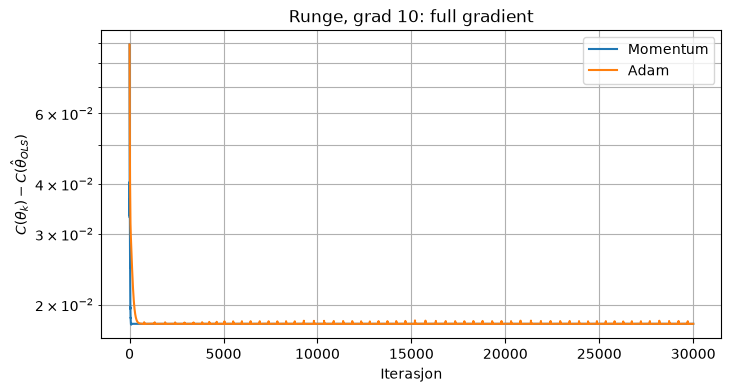

In [31]:
Ridge_1 = runge_comparison(degree=10, num_iters=30000, lam=1e-2)
print("-----")
Ridge_2 = runge_comparison(lam=10**(-2))

### 5c)

Take one Newton step from $\boldsymbol{\theta}_0 = \boldsymbol{0}$ with the exact
Hessian $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ — or, following week 37, with
`jax.hessian` of your cost — and compare with the closed form. What did Newton
use that none of the first-order methods had, and why can we not simply do
this for a neural network?

### 5d)

Finally, minibatches: run SGD with Adam ($M = 10$, a decaying schedule of
your choice, 500 epochs) on the degree-10 problem and compare the excess cost
per gradient evaluation with the full-gradient Adam run of 5a). Give a
critical assessment, in the spirit of part h) of Project 1: what has the noise
bought, and what has it cost?

In [ ]:
# Your code for exercise 5 here

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| Adam converged for every learning rate from $10^{-3}$ to $1$ and plain gradient descent only in a narrow window. Does $\gamma$ not matter for Adam? | It matters for speed, not for stability: the adaptive step is at most $\gamma$ per coordinate (division by $\sqrt{\hat v}$), so $\gamma$ is a *length in parameter space* and cannot violate Eq. (4.20) — but the best $\gamma$ was still several times faster than the worst. |
| RMSProp at a constant $\gamma$ never reached $10^{-6}$ on a convex quadratic. Why? | Near the minimum $r \approx g^2$ and the step is $\approx \gamma\,\mathrm{sign}(g)$, a fixed length that cannot shrink: the iterate rattles at radius $\sim\gamma$. It needs a decaying $\gamma$ (Eq. 4.40), or the first moment — which is Adam. |
| AdaGrad was slower than plain gradient descent on the degree-6 Runge problem. Is it broken? | No: $\boldsymbol{r}_t$ never forgets, Eq. (4.42), so the effective learning rate decays like $1/\sqrt t$ whether or not the minimum is near. That is the wrong behaviour on a smooth convex problem and the right one for sparse features, which it was designed for. |
| Why does Adam divide its moments by $1 - \beta_i^t$? | Both averages start from zero, so $\mathbb{E}[v_t] = (1-\beta_2^t)\,\mathbb{E}[g^2]$, Eq. (4.53): at $t=1$ the raw second moment is a thousand times too small and the step would be $\sqrt{1000}/\sqrt{10}\approx 3$ times too long. Dividing by the known factor removes the bias exactly; for large $t$ the correction vanishes. |
| What does "adaptive" mean, in one sentence? | Each coordinate gets its own step $\gamma/\sqrt{v_j}$, with $v_j$ the recent mean square gradient as a proxy for the curvature $\lambda_j$: a diagonal, $\mathcal{O}(p)$ imitation of Newton's $\boldsymbol{H}^{-1/2}$ (Section 4.8). |
| Rotating the bowl by $45^\circ$ left plain gradient descent unchanged and made AdaGrad and RMSProp fail. Why? | Eq. (4.19) depends on the eigenvalues only, which a rotation preserves; the adaptive methods rescale *coordinates* and see only the diagonal of $\boldsymbol{H}$. A valley that is not axis-aligned — a correlated polynomial basis, for instance — has its curvature off the diagonal. |
| Every first-order method stalled at an excess cost of $10^{-3}$ on the degree-10 Runge problem, and one Newton step solved it. What did Newton have? | The full Hessian, off-diagonal entries included: $\kappa = 2\times10^6$ is invisible to it, Eq. (4.8). We cannot afford it for a network ($\mathcal{O}(p^3)$); every method from momentum to Adam is a cheaper approximation to it. |
| Book Table 4.1: no optimiser is best at the same $\gamma$ as any other. What does that mean for comparing methods? | A learning rate is not comparable across optimisers — plain descent multiplies the gradient by $\gamma$, the adaptive methods normalise it first. Compare methods at each one's *best* $\gamma$, found by a scan, never at one shared value. |
| Plain SGD with $M=5$ sat at a distance $5\times10^{-2}$ from the minimum for ninety epochs. Has it converged? | No, it has equilibrated: the minibatch gradient is an unbiased estimate with noise $\propto 1/\sqrt M$ (Section 2.5), and at constant $\gamma$ the iterate is a random walk in a cloud of radius $\propto\sqrt\gamma/\sqrt M$. A longer run does not help; a smaller $\gamma$, a larger $M$ or a decaying $\gamma_t$ does. |
| Full-batch gradient descent beat SGD per gradient evaluation on the degree-2 data. Is SGD overrated? | On a small benign problem the exact gradient is cheap and converges geometrically, Eq. (4.26). For $n = 10^6$ one full gradient costs $10^4$ minibatch steps: per unit of computation SGD is far ahead, and it never needs the whole data set in memory — which is why every framework is built on minibatches. |
| The schedule $(t_0,t_1)=(1,10)$ worked at degree 2 and froze at degree 5. Which condition did it break? | Robbins–Monro needs $\sum_t\gamma_t = \infty$; in a finite run $\gamma_t = t_0/(t+t_1)$ with a small $t_1$ decays so fast that the accumulated step cannot cross a $\kappa = 520$ valley. Keep $\gamma_0 = t_0/t_1$ and enlarge both, so the decay starts later. |
| SGD with $M=1$ diverged at a $\gamma$ below $2/\lambda_{\max}$ of the full Hessian. How? | A minibatch step sees the Hessian of the *minibatch* cost; for one point it is $2\boldsymbol{x}_i\boldsymbol{x}_i^T$ with eigenvalue $2\|\boldsymbol{x}_i\|^2$, far above the average. The full-batch bound is a bound on the average, not on every step. |
| When should I stop a stochastic run? | Not on the gradient: monitor the validation cost and stop when it rises while the training cost still falls (early stopping, Section 4.7.1) — a regularisation method as much as a termination rule. |


### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 18 at midnight**. Collaboration is encouraged — list
your collaborators.